# Selección de características por estabilidad — una sola variante

Búsqueda de alfa disciplinada por DSR. La selección **no es un torneo**: se corre
una vez sobre *discovery* y el criterio es la **estabilidad de selección** (¿la
variable sobrevive en el 80%+ de los bootstraps?), **nunca** el Sharpe de validación.

El argumento:

- Si no puedes atar cada candidata a una **hipótesis económica**, no tienes
  hipótesis: cualquier reducción de 20→4 sería descubrimiento dirigido por datos,
  justo lo que infla el presupuesto DSR.
- La salida legítima no es "probar 5 subconjuntos y quedarme con el mejor OOS".
  Es un método de **una sola variante**: ElasticNet + bootstrap de árboles poco
  profundos sobre discovery, corrido una vez.
- Te quedas con las que superan el **umbral de estabilidad**, no las de mejor
  coeficiente. Si sobreviven más de 5, recortas por **parsimonia**, no por
  rendimiento.
- El **OOS protegido** está sellado y no se toca hasta el gate final, una vez.

> Este notebook narra el proceso e importa la lógica ya testeada de
> `src/alpha_selection`. Los datos aquí son **sintéticos con estructura conocida**
> (4 señales plantadas + 12 de ruido) para comprobar que el motor recupera lo real
> y descarta lo espurio.

## 0. Setup

In [1]:
import sys, os, tempfile, warnings
from pathlib import Path
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

from alpha_selection import (
    HypothesisRegistry, DataSplit, SealError,
    StabilityConfig, stability_select, render_report,
    log_variant, make_synthetic_discovery,
)

# Paleta colorblind-safe (diverging RdBu): superviviente vs descartada.
C_KEEP, C_DROP, C_THRESH = "#2166ac", "#b8b8b8", "#d6604d"

REGISTRY = "hypotheses/registry.yaml"
CONFIG   = "config/selection.yaml"
print("Setup OK")

Setup OK


## 1. El gate de hipótesis

Toda candidata cuelga de una hipótesis económica con `status: active`. Sin
hipótesis, no entra al pool. Esto convierte "no tengo hipótesis" en un error
explícito, no en una excusa.

In [2]:
reg = HypothesisRegistry.load(REGISTRY)
print(reg.gate_report())

gate = pd.DataFrame(
    [(f, reg.feature_to_hypothesis[f]) for f in reg.active_features],
    columns=["caracteristica", "hipotesis"],
)
gate

Hipótesis activas : 10
Candidatas (gate) : 16
En cuarentena     : 2 (fuera del pool)
Target / tarea    : spy_tp_hit / classification


,caracteristica,hipotesis
0,spy_mom_63,trend_persistence
1,spy_mom_252,trend_persistence
2,spy_ret_5,short_term_reversal
3,spy_vol_20,volatility_regime
4,spy_vol_ratio_20_60,volatility_regime
5,cyc_minus_def_mom_63,cyclical_leadership
6,xlk_rs_spy_20,cyclical_leadership
7,xlf_rs_spy_20,credit_risk_appetite
8,xle_rs_spy_20,energy_inflation_shock
9,sector_ret_dispersion_20,breadth_dispersion


## 2. Datos de discovery (sintéticos)

Panel diario con las 16 candidatas del registro. Solo 4 mueven de verdad el
target (las *señales verdaderas*); el resto es ruido, parte de él correlacionado
con las señales. El ratio señal/ruido es flojo a propósito.

In [3]:
from alpha_selection.synthetic import TRUE_SIGNAL
df = make_synthetic_discovery(n=1100, seed=7)
print("shape:", df.shape, "| tasa target:", round(df["spy_tp_hit"].mean(), 3))
print("señales verdaderas plantadas:", list(TRUE_SIGNAL))
df.head()

shape: (1100, 18) | tasa target: 0.49
señales verdaderas plantadas: ['spy_mom_63', 'cyc_minus_def_mom_63', 'macro_hy_oas', 'macro_vix_chg_5']


,date,spy_mom_63,spy_mom_252,spy_ret_5,spy_vol_20,spy_vol_ratio_20_60,cyc_minus_def_mom_63,xlk_rs_spy_20,xlf_rs_spy_20,xle_rs_spy_20,sector_ret_dispersion_20,sector_mom_mean_63,macro_yield_slope_10y2y,macro_hy_oas,macro_usd_broad_chg_20,macro_vix_level,macro_vix_chg_5,spy_tp_hit
0,2019-01-01,0.001230,0.241745,-0.274138,-0.890592,-0.249102,-0.991647,0.060144,1.340215,-0.492207,-0.620475,0.489842,0.356887,0.105414,-0.930468,-0.029252,0.695303,0
1,2019-01-02,-1.344215,-0.757440,-1.901223,-1.289538,-0.491465,-0.235091,-1.267446,0.271264,0.156751,-0.186931,-2.516760,-0.538693,-0.048501,0.113309,-1.530136,-0.477753,0
2,2019-01-03,-0.978519,-0.561960,1.060899,-0.807535,-0.680400,0.884390,-0.583600,-0.111702,0.110464,0.063782,-1.225056,0.076140,1.358823,-1.547145,0.859383,0.119354,1
3,2019-01-04,-0.641470,-0.566810,0.762260,-1.199289,-0.587638,0.576690,-0.188782,0.682910,-0.066517,0.667248,1.438523,-0.675662,0.203139,-0.463308,0.127268,-1.187195,1
4,2019-01-07,-0.579302,-0.339824,0.898764,1.145222,0.614456,-0.794642,0.646903,-1.992420,-0.463170,-0.097287,1.257015,0.689404,-0.327213,-0.368576,-0.250195,1.523529,0


## 3. Sello del OOS

El bloque OOS (aquí, la cola del panel) se sella: acceder a `.oos` lanza
`SealError`. Solo se rompe con `break_seal(reason=...)`, auditado, en el gate
final. Aquí la selección toca **solo** discovery.

In [4]:
split = DataSplit(df, oos_start="2022-01-01", date_col="date",
                  access_log=Path(tempfile.mkdtemp()) / "oos_access.jsonl")
print("split:", split.summary())

# Demostración: el OOS está sellado.
try:
    _ = split.oos
except SealError as e:
    print("\nSealError (correcto):", str(e)[:90], "...")

disc = split.discovery
print("\ndiscovery rows:", len(disc))

split: {'n_discovery': 784, 'n_oos': 316, 'oos_start': '2022-01-01', 'oos_fingerprint': '077c287f9b9416e6', 'seal_broken': False}

SealError (correcto): El OOS está sellado. No se toca durante la búsqueda de alfa. Para el gate final (una sola  ...

discovery rows: 784


## 4. Selección por estabilidad (una variante)

Dos lentes sobre el mismo discovery: ElasticNet (lineal) y bootstrap de árboles
poco profundos (no lineal), 200 bootstraps cada una. La frecuencia de selección
por característica es el criterio.

In [5]:
with open(CONFIG) as fh:
    cfg_d = yaml.safe_load(fh)
cfg_d["l1_ratios"] = tuple(cfg_d["l1_ratios"])
cfg = StabilityConfig(**cfg_d)
cfg.task = reg.task
print("config:", cfg.task, "| bootstraps:", cfg.n_bootstraps, "| umbral pi:", cfg.stability_threshold)

X = disc[reg.active_features].astype(float)
y = disc[reg.target_name]

result = stability_select(X, y, cfg)   # ~1-2 min (200 bootstraps x LogisticRegressionCV)

freq = (pd.DataFrame({
    "elasticnet": result.freq_elasticnet,
    "arbol": result.freq_tree,
    "combinada": result.freq_combined,
}).sort_values("combinada", ascending=False).round(3))
freq

config: classification | bootstraps: 200 | umbral pi: 0.8


,elasticnet,arbol,combinada
spy_mom_63,1.000,0.985,0.992
macro_hy_oas,1.000,0.985,0.992
macro_vix_chg_5,1.000,0.895,0.948
cyc_minus_def_mom_63,1.000,0.845,0.922
sector_ret_dispersion_20,0.815,0.055,0.435
macro_yield_slope_10y2y,0.710,0.150,0.430
spy_ret_5,0.655,0.190,0.422
macro_usd_broad_chg_20,0.720,0.125,0.422
sector_mom_mean_63,0.765,0.075,0.420
xle_rs_spy_20,0.725,0.115,0.420


## 5. Visualización — frecuencia de selección

Barra horizontal ordenada; la línea roja es el umbral π. Las que lo superan (según
el agregador `intersection`) son el conjunto estable. Nótese que las 4 señales
verdaderas se separan del ruido, y las candidatas colineales de ruido
(`spy_mom_252`, `spy_vol_ratio_20_60`) no alcanzan el umbral.

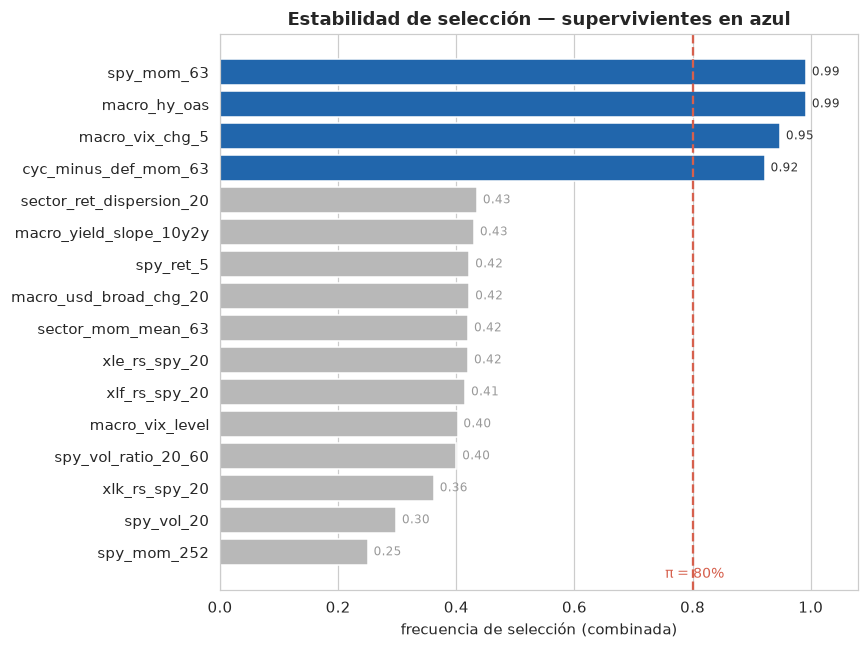

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
order = freq.sort_values("combinada")
colors = [C_KEEP if f in result.stable_set else C_DROP for f in order.index]
ax.barh(order.index, order["combinada"], color=colors)
for f, v in order["combinada"].items():
    ax.text(v + 0.01, f, f"{v:.2f}", va="center", fontsize=8,
            color="#333" if f in result.stable_set else "#999")
ax.axvline(cfg.stability_threshold, color=C_THRESH, ls="--", lw=1.5)
ax.text(cfg.stability_threshold, -0.8, f" π = {cfg.stability_threshold:.0%}",
        color=C_THRESH, fontsize=9, ha="center")
ax.set_xlim(0, 1.08); ax.set_xlabel("frecuencia de selección (combinada)")
ax.set_title("Estabilidad de selección — supervivientes en azul")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 6. Recorte por parsimonia y conjunto final

Si sobreviven más de `max_features` (5), se recorta por reproducibilidad +
de-correlación — **nunca** por rendimiento. Aquí no hace falta recortar.

In [7]:
print("Conjunto estable ( >= pi ):", result.stable_set)
print("Recortadas por parsimonia :", result.dropped_for_parsimony)
print("CONJUNTO FINAL            :", result.final_set)

Conjunto estable ( >= pi ): ['macro_hy_oas', 'spy_mom_63', 'macro_vix_chg_5', 'cyc_minus_def_mom_63']
Recortadas por parsimonia : []
CONJUNTO FINAL            : ['macro_hy_oas', 'spy_mom_63', 'macro_vix_chg_5', 'cyc_minus_def_mom_63']


## 7. Registro de la variante (contabilidad DSR)

Un run = una línea en el log. Es la contabilidad honesta de cuántas variantes has
probado, que es justo lo que el Deflated Sharpe Ratio necesita. *(Aquí se escribe
a un log temporal para no contaminar el ledger versionado del repo.)*

In [8]:
demo_log = Path(tempfile.mkdtemp()) / "variants_demo.jsonl"
from alpha_selection.splits import _fingerprint
data_fp = _fingerprint(disc[reg.active_features + [reg.target_name]])
record = log_variant(result, log_path=demo_log, data_fingerprint=data_fp,
                     label="demo-sintetica", oos_fingerprint=split.oos_fingerprint,
                     notes="Notebook 1 — datos sintéticos")
print(f"Variante #{record['variant_index']} registrada")
print("  presupuesto DSR de selección:", record["variant_index"], "variante(s)")
print("  final_set:", record["final_set"])

Variante #1 registrada
  presupuesto DSR de selección: 1 variante(s)
  final_set: ['macro_hy_oas', 'spy_mom_63', 'macro_vix_chg_5', 'cyc_minus_def_mom_63']


## 8. Reporte y conclusiones

In [9]:
print(render_report(result))

SELECCIÓN POR ESTABILIDAD  —  una variante
Tarea               : classification
Muestras (discovery): 784
Candidatas          : 16
Bootstraps          : 200
Umbral estabilidad π: 80%
Agregador           : intersection
Tope parsimonia     : 5

Frecuencia de selección por característica
--------------------------------------------------------------------
característica                elasticnet     árbol   combinada  
--------------------------------------------------------------------
spy_mom_63                         1.00      0.98        0.99 *  <= estable
macro_hy_oas                       1.00      0.98        0.99 *  <= estable
macro_vix_chg_5                    1.00      0.90        0.95 *  <= estable
cyc_minus_def_mom_63               1.00      0.84        0.92 *  <= estable
sector_ret_dispersion_20           0.81      0.06        0.43  
macro_yield_slope_10y2y            0.71      0.15        0.43  
spy_ret_5                          0.66      0.19        0.42  
macro_usd_broad

### Conclusión

El motor recupera exactamente las 4 señales plantadas y deja el ruido (incluido el
ruido **colineal**) por debajo del umbral. La lente de árboles es la que más
discrimina; la intersección con ElasticNet limpia los falsos positivos lineales.

Lo importante metodológicamente: esto fue **una** variante. El criterio fue
estabilidad, no Sharpe. Y el OOS nunca se tocó. Con datos reales, si nada supera el
umbral, la respuesta correcta no es aflojar π — es que no hay estructura
reproducible y toca revisar las hipótesis.